In [43]:
import numpy as np
import random
import matplotlib.pyplot as plt
from scipy import stats
n = 10
probs = np.random.rand(n)
eps = 0.2

In [44]:
#reward
def get_reward(prob):
    reward = 0
    for i in range(10):
        if random.random() < prob:
            reward += 1
    return reward

In [45]:
#env
def update_record(record,action,r):
    r_ave = (record[action,0]*record[action,1]+r)/(record[action,1]+1)
    record[action,0] += 1
    record[action,1] = r_ave
    return record

In [46]:
#action
def get_best_arm(record):
    arm_index = np.argmax(record[:,1])
    return arm_index

Text(0, 0.5, 'reward')

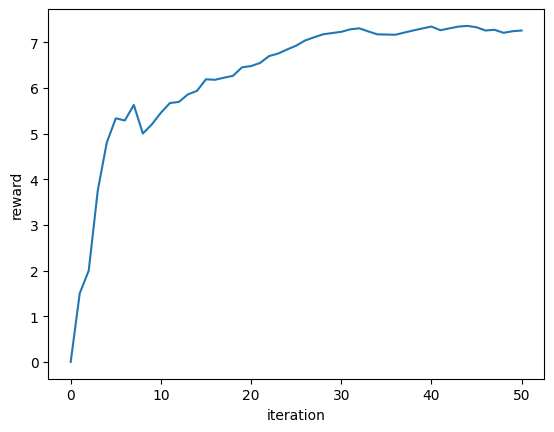

In [53]:
record = np.zeros((n,2))
reward=[0]
choices = []
for i in range(50):
    if random.random() > eps:
        choice = get_best_arm(record)
    else:
        choice = random.randint(0,n-1)
    choices.append(choice)
    r = get_reward(probs[choice])
    record = update_record(record,choice,r)
    mean_reward = ((i+1)*reward[-1]+r)/(i+2)
    reward.append(mean_reward)
plt.plot(reward)
plt.xlabel('iteration')
plt.ylabel('reward')


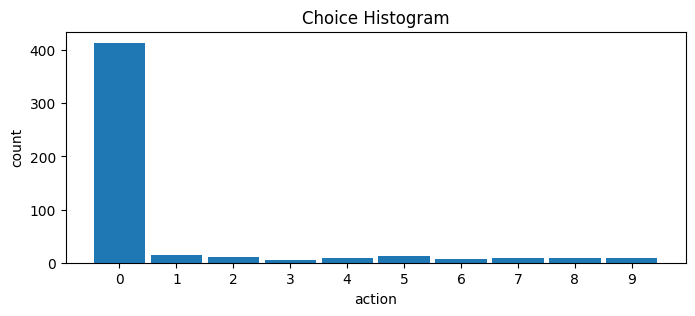

In [48]:
plt.figure(figsize=(8,3))
plt.hist(choices, bins=np.arange(-0.5, n + 0.5, 1), rwidth=0.9)
plt.xticks(range(n))
plt.xlabel('action')
plt.ylabel('count')
plt.title('Choice Histogram')
plt.show()


## 上面是基礎版，透過學習過往經驗找到機率，下為延伸

In [ ]:
#在探索時上面用到random太粗糙，可以使用softmax來選擇action
#softmax函數會將輸入的數值轉換成機率分布，讓較大的數值有較高的機率被選擇，較小的數值則有較低的機率被選擇。這樣可以在探索時更有策略性地選擇action，而不是完全隨機。
#temp參數控制了探索的程度，較高的temp會使得機率分布更平坦，增加探索的機會；較低的temp則會使得機率分布更陡峭，增加利用的機會。
def softmax(x,temp = 1.2):
    softm = np.exp(x/temp)/np.sum(np.exp(x/temp))
    return softm #返回機率分布，例如softmax([1,2,3])返回[0.09003057 0.24472847 0.66524096]

Text(0, 0.5, 'reward')

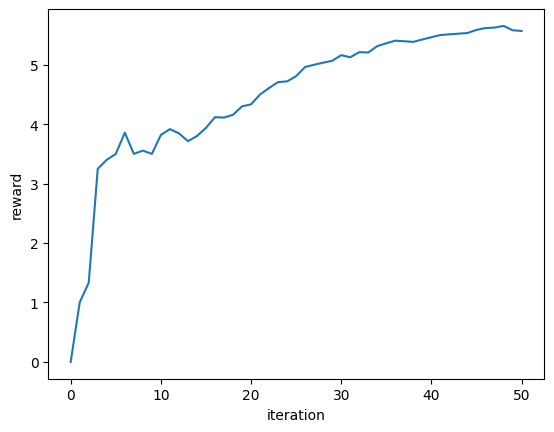

In [52]:
record = np.zeros((n,2))
reward=[0]
choices = []
for i in range(50):
    choice = np.random.choice(n, p=softmax(record[:,1]))
    choices.append(choice)
    r = get_reward(probs[choice])
    record = update_record(record,choice,r)
    mean_reward = ((i+1)*reward[-1]+r)/(i+2)
    reward.append(mean_reward)
plt.plot(reward)
plt.xlabel('iteration')
plt.ylabel('reward')


# 剛剛那西都是只有一個狀態(probs不變)，下面用多state帶入nn

In [58]:
import torch

In [ ]:
# environment
class ContextBandit:
    def __init__(self,arms = 10):
        self.arms = arms
        self.init_distribution(arms)
        self.update_state()
    def init_distribution(self,arms): 
        states = arms
        self.bandit_matrix = np.random.rand(states, arms)
    def update_state(self):
        self.state = np.random.randint(0,self.arms)
    def reward(self,probs):
        reward=0
        for i in range(10):
            if random.random() < probs:
                reward += 1
        return reward
    def get_state(self):
        return self.state
    def get_reward(self,arm):
        return self.reward(self.bandit_matrix[self.get_state(),arm])
    def choice_arm(self,arm):
        reward = self.get_reward(arm)
        self.update_state()
        return reward


In [57]:
env = ContextBandit(arms=10)
state = env.get_state()
reward = env.choice_arm(1)
print(f'state: {state}, reward: {reward}')

state: 2, reward: 8


In [60]:
model = torch.nn.Sequential(
    torch.nn.Linear(10,100),
    torch.nn.ReLU(),
    torch.nn.Linear(100,10),
    torch.nn.ReLU()
)

loss_fn = torch.nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)

In [61]:
def one_hot(N, pos,val = 1):
    one_hot_vector = np.zeros(N)
    one_hot_vector[pos] = val
    return one_hot_vector

In [125]:
def train(model, env, loss_fn, optimizer, episodes=1000, device=None):
    if device is None:
        device = torch.device("cuda")

    model = model.to(device)
    reward_history = []
    state_history = []
    cur_state = torch.tensor(
        one_hot(env.arms, env.get_state()),
        dtype=torch.float32,
        device=device
    )

    for episode in range(episodes):
        y_pred = model(cur_state)  # on device

        # 用 torch softmax，最後才轉 CPU 給 np.random.choice
        probs = softmax(y_pred.detach().data.cpu().numpy())
        choice = np.random.choice(env.arms, p=probs)

        cur_reward = env.choice_arm(choice)
        state_history.append(env.get_state())
        one_hot_reward = y_pred.data.cpu().numpy().copy()
        one_hot_reward[choice] = cur_reward
        reward = torch.tensor(one_hot_reward, dtype=torch.float32, device=device)
        reward_history.append(cur_reward)


        loss = loss_fn(y_pred, reward)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        cur_state = torch.tensor(
            one_hot(env.arms, env.get_state()),
            dtype=torch.float32,
            device=device
        )

    return reward_history,state_history
reward, state_history = train(model, env, loss_fn, optimizer, episodes=10000)


Text(0, 0.5, 'reward')

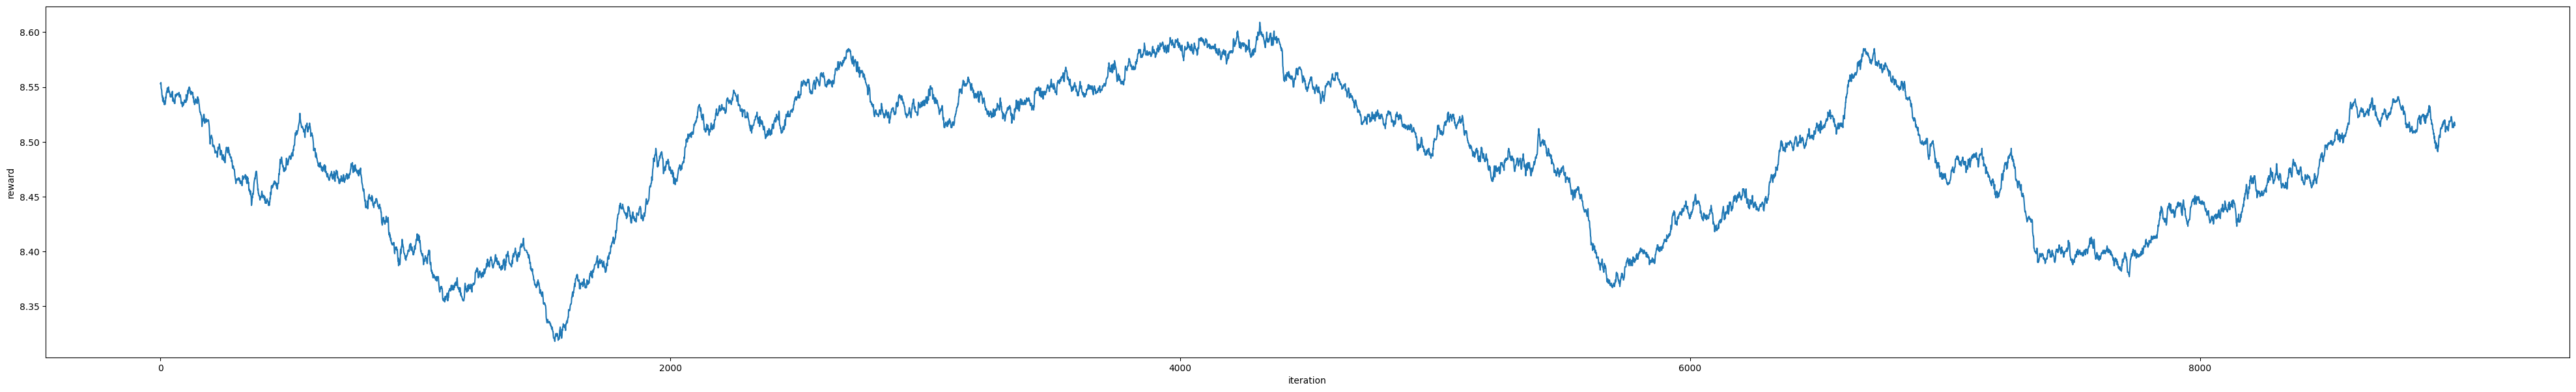

In [137]:
def running_mean(x, N):
    c = x.shape[0]-N
    y = np.zeros(c)
    conv = np.ones(N)
    for i in range(c):
        y[i] = np.sum(x[i:i+N] @ conv)/N
    return y

reward_np = np.array([r.detach().cpu().item() if torch.is_tensor(r) else float(r) for r in reward])
plt.figure(figsize=(50,7))
plt.plot(running_mean(reward_np, 1000))
plt.xlabel('iteration')
plt.ylabel('reward')


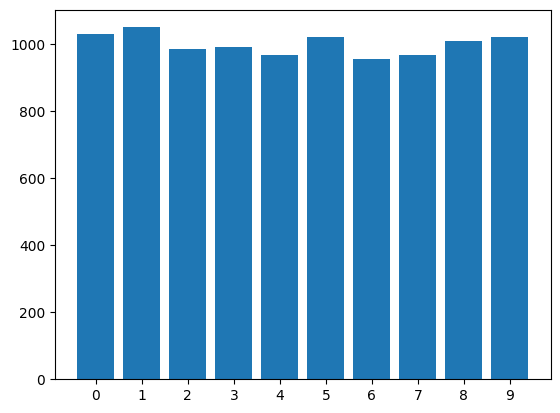

In [131]:
plt.hist(state_history, bins=np.arange(-0.5, env.arms + 0.5, 1), rwidth=0.8)
plt.xticks(range(env.arms))
plt.show()

In [132]:
model.eval()
with torch.no_grad():
    y_pred = model(torch.tensor([0,0,0,1,0,0,0,0,0,0], dtype=torch.float32, device= "cuda"))#預測在state 3下，每個action的reward
    print("Predicted rewards for each arm:", y_pred.cpu().numpy())

Predicted rewards for each arm: [6.350484  8.857045  5.087915  8.2893915 8.822928  4.2914023 4.924182
 4.5016236 0.        5.420609 ]


In [133]:
print(env.bandit_matrix[3]*10 )#數字表示在state 3下，每個action的reward機率


[6.21188664 8.90834628 4.39941444 8.4527317  8.96097425 2.02613753
 3.98504308 0.67153936 9.07262561 4.40279067]


In [134]:
ave = abs(y_pred.cpu().numpy() - env.bandit_matrix[3]*10)
print(ave)
print("Average absolute error:", np.mean(ave))

[0.13859726 0.0513011  0.6885005  0.16334018 0.13804582 2.26526481
 0.93913886 3.83008427 9.07262561 1.01781832]
Average absolute error: 1.8304716740945601
